In [23]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [24]:
def is_safe(v, selected_nodes, graph):
    if v in selected_nodes:
        return False
    
    for neighbor in graph[v]:
        if neighbor in selected_nodes:
            return False
        
    return True

def can_p2_win(selected, p2_score, turn_p1):
    available = []
    for v in graph:
        if is_safe(v, selected, graph):
            available.append(v)

    if not available:
        return p2_score >= target_B
    
    if turn_p1:
        for move in available:
            if not can_p2_win(selected + [move], p2_score, False):
                return False
        return True
    
    else:
        for move in available:
            if can_p2_win(selected + [move], p2_score + weights[move], True):
                return True
        return False

In [25]:
graph = {0 :[1],
         1 :[0, 2],
         2 :[1, 3],
         3 :[2, 4],
         4 :[3, 5],
         5 :[4, 6],
         6 :[5, 7],
         7 :[6, 8],
         8 :[7, 9],
         9 :[8]}

weights = [10, 1, 5, 15, 5, 1, 5, 1, 15, 10]

target_B = 20

start = time.perf_counter()

print(can_p2_win([], 0, True))

finish = time.perf_counter()
print(f"Время{finish - start}")

True
Время0.0010930830030702055


In [26]:
times = []

for _ in range(100):
    start = time.perf_counter()
    result = can_p2_win([], 0, True)
    end = time.perf_counter()
    times.append(end - start)

print("Результат:", result)
print(times)

Результат: True
[0.0006861250149086118, 0.000537916028406471, 0.0007087920093908906, 0.0005355410394258797, 0.0005348330014385283, 0.0005344580276869237, 0.0005352920270524919, 0.0005112919607199728, 0.0005023340345360339, 0.0007530840230174363, 0.0005060840048827231, 0.0005032090120948851, 0.0005029169842600822, 0.0005009170272387564, 0.0005015830392949283, 0.0005048339953646064, 0.0005020000389777124, 0.0005477499798871577, 0.0004866250092163682, 0.00047212501522153616, 0.0004712919471785426, 0.0005249580135568976, 0.000479582988191396, 0.0004876669845543802, 0.0004749169456772506, 0.00047562504187226295, 0.00047450000420212746, 0.00047437497414648533, 0.00047324999468401074, 0.0004826249787583947, 0.00046974996803328395, 0.00045058398973196745, 0.00047254201490432024, 0.0004504999960772693, 0.0005326249520294368, 0.000496583990752697, 0.0004504579701460898, 0.00046329095494002104, 0.000447333964984864, 0.00044533301843330264, 0.00044583401177078485, 0.0004617919912561774, 0.00044379

In [27]:
times = np.array(times)
times.mean(), times.std()

(0.00045547505957074466, 6.979905611499622e-05)

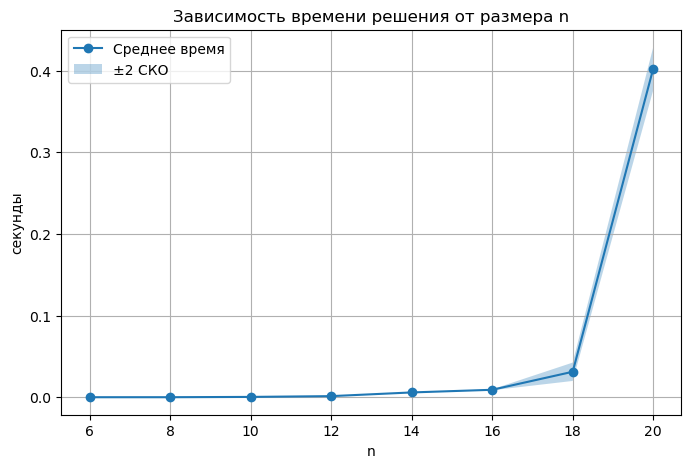

In [28]:
def make_graph(n):
    g = {}
    for i in range(n):
        g[i] = []
        if i - 1 >= 0:
            g[i].append(i - 1)
        if i + 1 < n:
            g[i].append(i + 1)
    return g

pattern = weights[:]

ratio = target_B / sum(weights)

ns = [6, 8, 10, 12, 14, 16, 18, 20]

means = []
stds = []

for n in ns:
    graph = make_graph(n)
    weights = [pattern[i % len(pattern)] for i in range(n)]
    target_B = round(sum(weights) * ratio)

    times = []

    for _ in range(20):
        start = time.perf_counter()
        can_p2_win([], 0, True)
        finish = time.perf_counter()
        times.append(finish - start)

    times = np.array(times)
    means.append(times.mean())
    stds.append(times.std())

means = np.array(means)
stds = np.array(stds)

plt.figure(figsize=(8, 5))
plt.plot(ns, means, marker='o', label='Среднее время')
plt.fill_between(ns, means - 2 * stds, means + 2 * stds, alpha=0.3, label='±2 СКО')

plt.xlabel('n')
plt.ylabel('секунды')
plt.title('Зависимость времени решения от размера n')
plt.grid(True)
plt.legend()
plt.show()

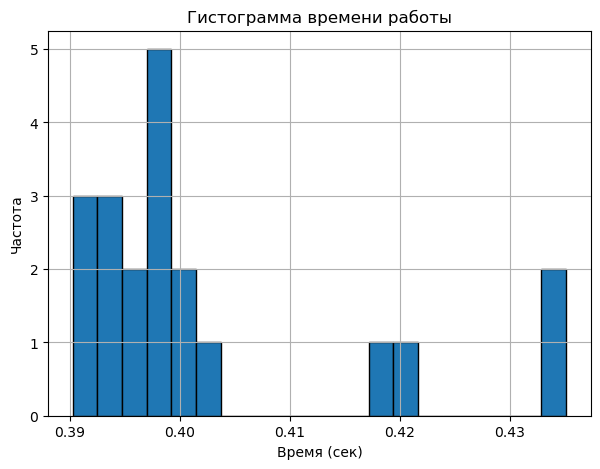

In [29]:
plt.figure(figsize=(7, 5))
plt.hist(times, bins=20, edgecolor='black')

plt.xlabel('Время (сек)')
plt.ylabel('Частота')
plt.title('Гистограмма времени работы')
plt.grid(True)
plt.show()

In [30]:
mu = times.mean()
sigma = times.std()

D, p_value = stats.kstest(times, 'norm', args=(mu, sigma))

print("Среднее:", mu)
print("СКО:", sigma)
print("D-статистика:", D)
print("p-value:", p_value)

if p_value > 0.05:
    print("Гипотеза не отвергается")
else:
    print("Гипотеза отвергается")

Среднее: 0.40233200834773014
СКО: 0.013150853377587078
D-статистика: 0.30294787001931933
p-value: 0.03993745668642157
Гипотеза отвергается
